In [13]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, InMemoryDataset, DataLoader
from ogb.utils import smiles2graph
from rdkit import Chem
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm
from scripts.regression_plots import prediction_plot, learning_curve_plot, gaussian_fit
import pandas as pd
from scripts.preprocessing import PDBpreprocessing
raw_data = pd.read_csv("data/LP_PDBBind.csv")


# Part 1: Graph Neural Network that predict target values (ln(kd or ki)) from tha smiles 

In [14]:
preprocessed_data = PDBpreprocessing(raw_data, category= None, variable='both', keep_protein_chain=False, log_transform=True)
print(preprocessed_data.shape)
preprocessed_data.head()

✅ Cleaned dataset shape: (19121, 2)
   Dropped rows with None/NaN in ['smiles', 'target']
(19121, 2)


,smiles,target
0,CSc1ccccc1[C@H]1CCCN1C(=O)CNC(=O)NCc1ccc2c(c1)...,1.796016
1,O=C([O-])CCC[N@H+]1CCC[C@H]1COc1ccc(Oc2ccc(Cl)...,3.223619
2,CCC(CC)O[C@@H]1C[C@H](C(=O)[O-])C[C@H]([NH3+])...,-1.473654
3,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,11.121486
4,[NH3+][C@@H](C[C@]1(C(=O)[O-])C[C@H]2OCC[C@@H]...,5.134765


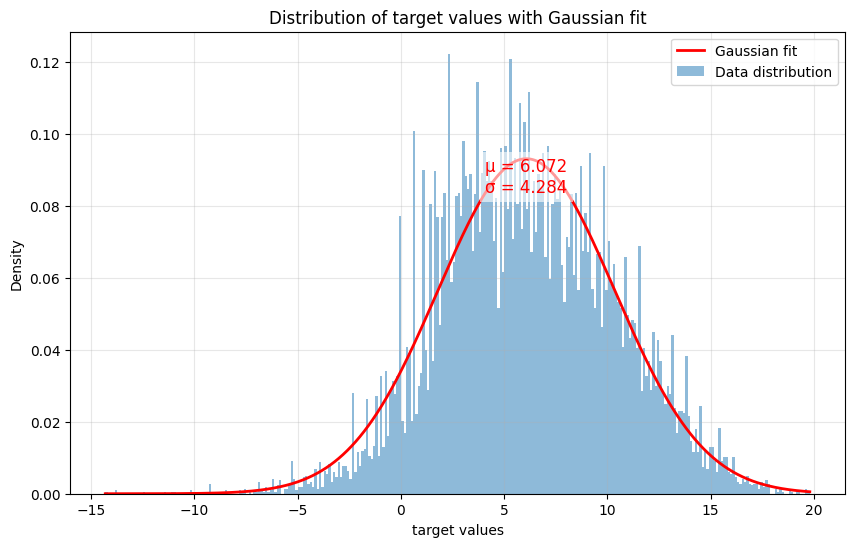

In [15]:
# Extract data
data = preprocessed_data['target'].dropna().values
gaussian_fit(data)

[22:07:13] Explicit valence for atom # 34 N, 4, is greater than permitted
[22:07:13] Unusual charge on atom 1 number of radical electrons set to zero
[22:07:13] Unusual charge on atom 2 number of radical electrons set to zero
[22:07:13] Unusual charge on atom 36 number of radical electrons set to zero
[22:07:13] Unusual charge on atom 12 number of radical electrons set to zero
[22:07:13] Unusual charge on atom 16 number of radical electrons set to zero
[22:07:14] Explicit valence for atom # 3 N, 4, is greater than permitted
[22:07:14] Explicit valence for atom # 7 Cl, 3, is greater than permitted
[22:07:14] Unusual charge on atom 17 number of radical electrons set to zero
[22:07:14] Unusual charge on atom 16 number of radical electrons set to zero
[22:07:15] Unusual charge on atom 13 number of radical electrons set to zero
[22:07:15] Explicit valence for atom # 3 N, 4, is greater than permitted
[22:07:16] Unusual charge on atom 18 number of radical electrons set to zero
[22:07:16] Unus

✅ Dataset built: 19115 molecules
Node feature dim: 9


c:\Users\33695\Documents\GitHub\cheminfo_project\.venv\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 001 | Train Loss: 22.8277 | Val Loss: 18.6736
Epoch 002 | Train Loss: 18.1834 | Val Loss: 18.4063
Epoch 003 | Train Loss: 18.0170 | Val Loss: 18.2274
Epoch 004 | Train Loss: 17.8889 | Val Loss: 18.1268
Epoch 005 | Train Loss: 17.8101 | Val Loss: 18.2005
Epoch 006 | Train Loss: 17.7514 | Val Loss: 17.9724
Epoch 007 | Train Loss: 17.6755 | Val Loss: 17.9214
Epoch 008 | Train Loss: 17.6220 | Val Loss: 17.8651
Epoch 009 | Train Loss: 17.5946 | Val Loss: 17.8116
Epoch 010 | Train Loss: 17.5350 | Val Loss: 17.8959
Epoch 011 | Train Loss: 17.5117 | Val Loss: 17.7593
Epoch 012 | Train Loss: 17.4322 | Val Loss: 17.8236
Epoch 013 | Train Loss: 17.3854 | Val Loss: 17.7824
Epoch 014 | Train Loss: 17.3497 | Val Loss: 17.6067
Epoch 015 | Train Loss: 17.3559 | Val Loss: 17.5751
Epoch 016 | Train Loss: 17.3035 | Val Loss: 17.5681
Epoch 017 | Train Loss: 17.2611 | Val Loss: 17.5994
Epoch 018 | Train Loss: 17.2295 | Val Loss: 17.5577
Epoch 019 | Train Loss: 17.2260 | Val Loss: 17.4877
Epoch 020 | 

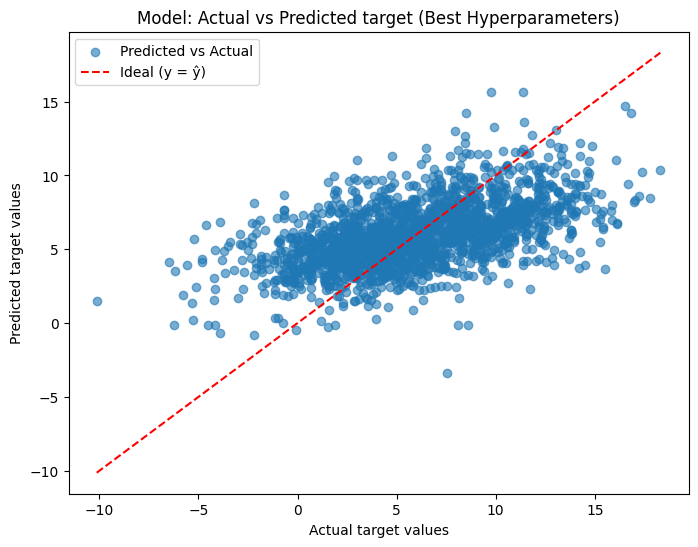

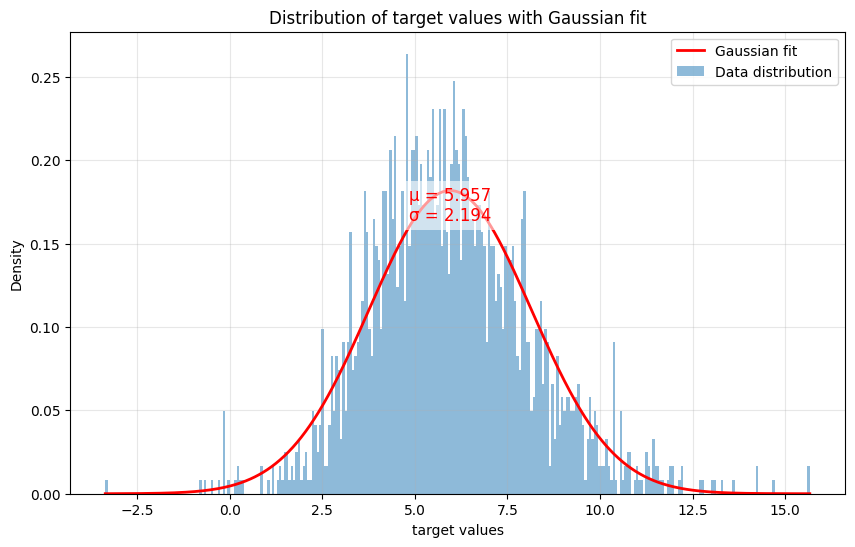

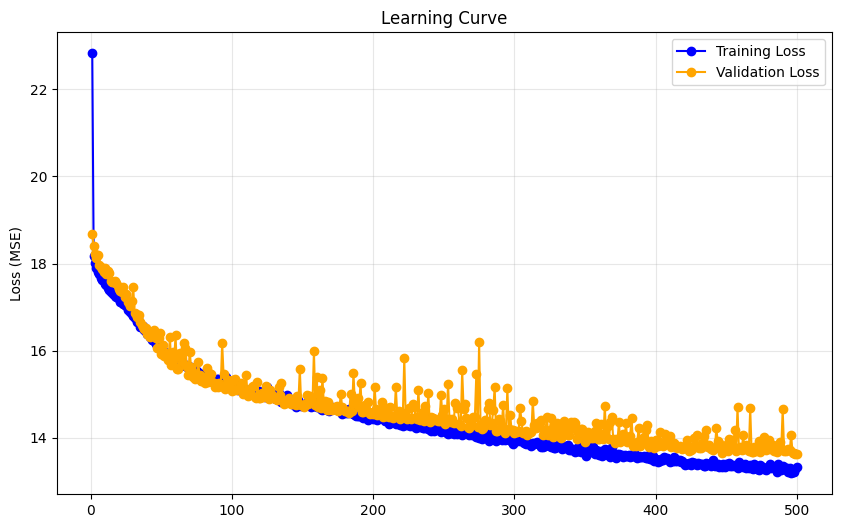

In [16]:
# ------------------------------
# Config
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_dim = 64
batch_size = 64
epochs = 500
lr = 0.5e-3

# ===============================================
# Step 1 — Build dataset from preprocessed_data
# ===============================================

preprocessed_data = preprocessed_data[preprocessed_data['smiles'].apply(lambda s: isinstance(s, str) and Chem.MolFromSmiles(s) is not None)].reset_index(drop=True)

class InMemorySMILESDataset(InMemoryDataset):
    def __init__(self, df, transform=None, pre_transform=None):
        self.df = df.reset_index(drop=True)
        super().__init__(None, transform, pre_transform)
        self.data, self.slices = self.process_df()

    def process_df(self):
        data_list = []
        for smiles, y in tqdm(zip(self.df["smiles"], self.df["target"]), total=len(self.df), desc="Converting SMILES"):
            graph = smiles2graph(smiles)
            x = torch.tensor(graph["node_feat"], dtype=torch.float)
            edge_index = torch.tensor(graph["edge_index"], dtype=torch.long)
            edge_attr = torch.tensor(graph["edge_feat"], dtype=torch.float)
            y = torch.tensor([y], dtype=torch.float)
            data_list.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y))
        return self.collate(data_list)

# Create dataset directly from your DataFrame
dataset = InMemorySMILESDataset(preprocessed_data)
print(f"✅ Dataset built: {len(dataset)} molecules")
print(f"Node feature dim: {dataset[0].x.shape[1]}")

# ===============================================
# Step 2 — Train / Val / Test Split
# ===============================================
num_graphs = len(dataset)
train_len = int(0.8 * num_graphs)
val_len = int(0.1 * num_graphs)
test_len = num_graphs - train_len - val_len

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ===============================================
# Step 3 — Model Definition (OGB-style)
# ===============================================
class GCNRegression(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, out_dim=1):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = torch.nn.Linear(hidden_dim, out_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).view(-1)

# Initialize model
model = GCNRegression(dataset[0].x.shape[1], hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()

# ===============================================
# Step 4 — Training Loop
# ===============================================
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            val_loss += loss_fn(out, batch.y.view(-1)).item() * batch.num_graphs
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# ===============================================
# Step 5 — Evaluation on Test Set
# ===============================================
model.eval()
ys, preds = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        ys.append(batch.y.view(-1).cpu().numpy())
        preds.append(out.cpu().numpy())

ys = np.concatenate(ys)
preds = np.concatenate(preds)

mse = mean_squared_error(ys, preds)
r2 = r2_score(ys, preds)
print(f"\nTest MSE: {mse:.4f} | R²: {r2:.4f}")
# Plot predictions
prediction_plot(ys, preds)
gaussian_fit(preds)  # Residuals analysis
# Plot learning curve
learning_curve_plot(train_losses, val_losses)

# Contextual GNN: Context = one hot encoded protein (amino acod frequencies) vector embedded in each node of the molecules

✅ Cleaned dataset shape: (19121, 3)
   Dropped rows with None/NaN in ['smiles', 'target', 'seq']
(19121, 3)


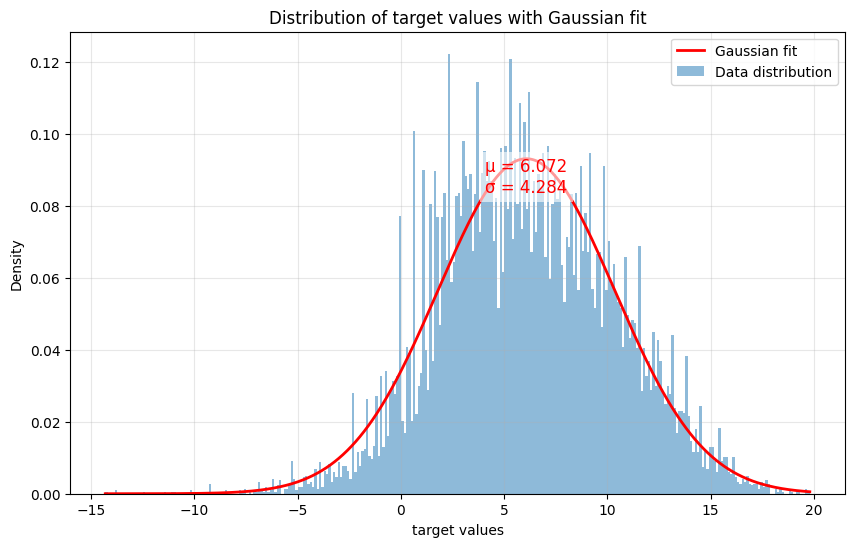

,smiles,target,seq
0,CSc1ccccc1[C@H]1CCCN1C(=O)CNC(=O)NCc1ccc2c(c1)...,1.796016,GNPLVYLDVDANGKPLGRVVLELKADVVPKTAENFRALCTGEKGFG...
1,O=C([O-])CCC[N@H+]1CCC[C@H]1COc1ccc(Oc2ccc(Cl)...,3.223619,VDTCSLASPASVCRTKHLHLRCSVDFTRRTLTGTAALTVQSQEDNL...
2,CCC(CC)O[C@@H]1C[C@H](C(=O)[O-])C[C@H]([NH3+])...,-1.473654,VKLAGNSSLCPVSGWAIYSKDNSVRIGSKGDVFVIREPFISCSPLE...
3,CC[C@H](C)[C@H](NC(=O)CNC(=O)[C@H](C)NC(=O)[C@...,11.121486,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...
4,[NH3+][C@@H](C[C@]1(C(=O)[O-])C[C@H]2OCC[C@@H]...,5.134765,ANRTLIVTTILEEPYVMYRKSDKPLYGNDRFEGYCLDLLKELSNIL...


In [17]:
preprocessed_data = PDBpreprocessing(raw_data, category= None, variable='both', keep_protein_chain=True, log_transform=True)
print(preprocessed_data.shape)
data = preprocessed_data['target'].dropna().values
gaussian_fit(data)
preprocessed_data.head()

[22:37:29] Explicit valence for atom # 34 N, 4, is greater than permitted
[22:37:29] Unusual charge on atom 1 number of radical electrons set to zero
[22:37:29] Unusual charge on atom 2 number of radical electrons set to zero
[22:37:29] Unusual charge on atom 36 number of radical electrons set to zero
[22:37:29] Unusual charge on atom 12 number of radical electrons set to zero
[22:37:30] Unusual charge on atom 16 number of radical electrons set to zero
[22:37:30] Explicit valence for atom # 3 N, 4, is greater than permitted
[22:37:30] Explicit valence for atom # 7 Cl, 3, is greater than permitted
[22:37:30] Unusual charge on atom 17 number of radical electrons set to zero
[22:37:30] Unusual charge on atom 16 number of radical electrons set to zero
[22:37:31] Unusual charge on atom 13 number of radical electrons set to zero
[22:37:31] Explicit valence for atom # 3 N, 4, is greater than permitted
[22:37:32] Unusual charge on atom 18 number of radical electrons set to zero
[22:37:32] Unus

✅ Dataset built: 19115 molecules
Node feature dim: 9


c:\Users\33695\Documents\GitHub\cheminfo_project\.venv\lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Epoch 001 | Train Loss: 20.9286 | Val Loss: 17.0923
Epoch 002 | Train Loss: 16.6784 | Val Loss: 16.3109
Epoch 003 | Train Loss: 16.2597 | Val Loss: 15.9510
Epoch 004 | Train Loss: 15.6948 | Val Loss: 16.3709
Epoch 005 | Train Loss: 15.4123 | Val Loss: 15.5312
Epoch 006 | Train Loss: 15.2006 | Val Loss: 15.3489
Epoch 007 | Train Loss: 15.0025 | Val Loss: 15.2411
Epoch 008 | Train Loss: 15.0873 | Val Loss: 14.9627
Epoch 009 | Train Loss: 14.5792 | Val Loss: 15.0538
Epoch 010 | Train Loss: 14.5468 | Val Loss: 15.2049
Epoch 011 | Train Loss: 14.2074 | Val Loss: 14.7997
Epoch 012 | Train Loss: 14.1754 | Val Loss: 14.7998
Epoch 013 | Train Loss: 13.9737 | Val Loss: 14.4014
Epoch 014 | Train Loss: 13.7963 | Val Loss: 14.4065
Epoch 015 | Train Loss: 13.6572 | Val Loss: 14.4558
Epoch 016 | Train Loss: 13.5281 | Val Loss: 14.1635
Epoch 017 | Train Loss: 13.3228 | Val Loss: 14.0551
Epoch 018 | Train Loss: 13.3717 | Val Loss: 14.0320
Epoch 019 | Train Loss: 13.0689 | Val Loss: 14.0913
Epoch 020 | 

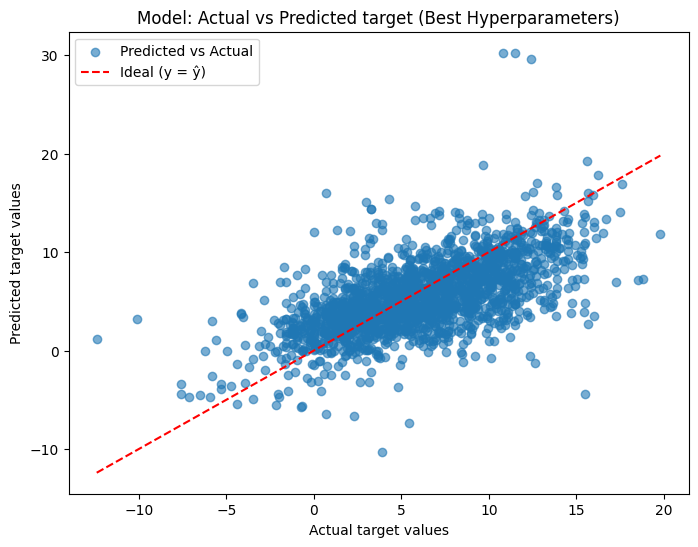

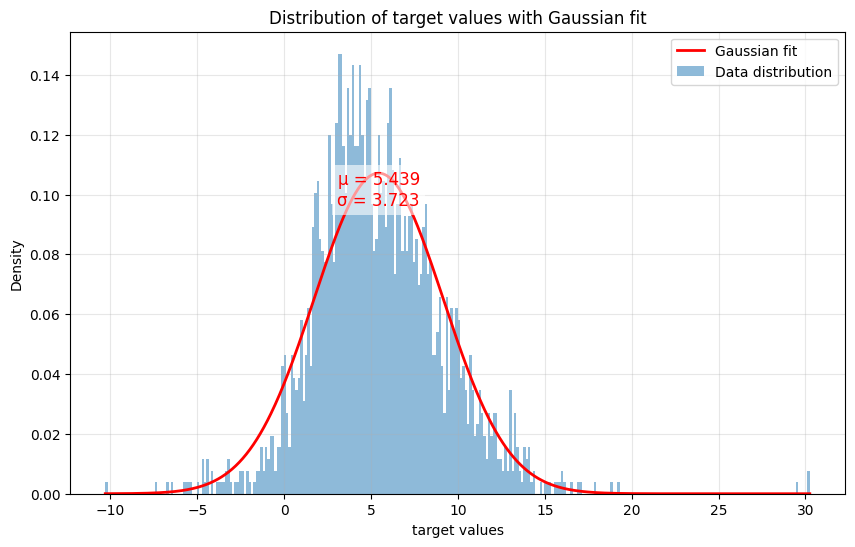

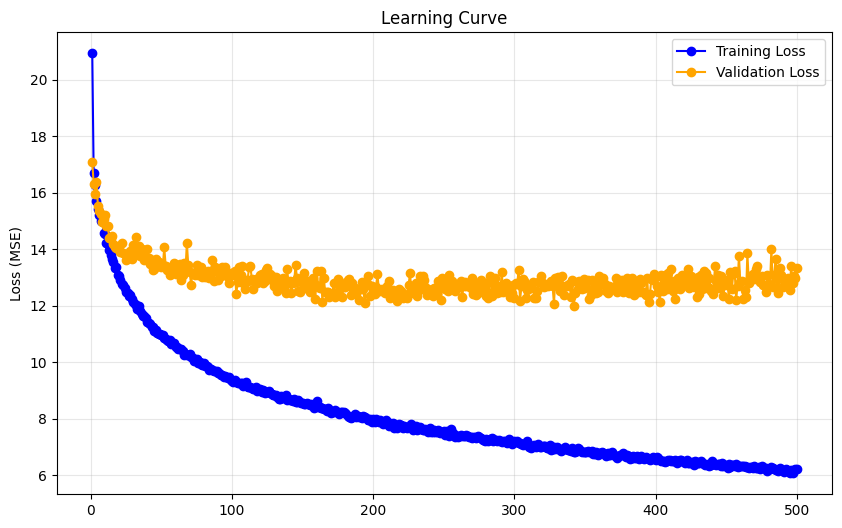

In [18]:
# ------------------------------
# Config
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hidden_dim = 64
batch_size = 64
epochs = 500
lr = 0.5e-3

# ===============================================
# Step 1 — Build dataset from preprocessed_data
# ===============================================
def protein_chain_encoder(chain):
    v = np.zeros(26)
    for i in range(len(chain)):
        aa = chain[i]
        if aa in 'ABCDEFGHIJKLMNOPQRSTUVWXYZ':
            v[ord(aa) - ord('A')] += 1
    return v

# pc = np.array([protein_chain_encoder(c) for c in preprocessed_data['seq']])
preprocessed_data = preprocessed_data[preprocessed_data['smiles'].apply(lambda s: isinstance(s, str) and Chem.MolFromSmiles(s) is not None)].reset_index(drop=True)

class InMemorySMILESDataset(InMemoryDataset):
    def __init__(self, df, transform=None, pre_transform=None):
        self.df = df.reset_index(drop=True)
        super().__init__(None, transform, pre_transform)
        self.data, self.slices = self.process_df()

    def process_df(self):
        data_list = []
        for smiles, seq, y in tqdm(zip(self.df["smiles"], self.df["seq"], self.df["target"]),
                                   total=len(self.df), desc="Converting SMILES + Protein"):
            graph = smiles2graph(smiles)
            x = torch.tensor(graph["node_feat"], dtype=torch.float)
            edge_index = torch.tensor(graph["edge_index"], dtype=torch.long)
            edge_attr = torch.tensor(graph["edge_feat"], dtype=torch.float)
            y = torch.tensor([y], dtype=torch.float)

            # Encode the protein chain (frequency vector)
            prot_vec = torch.tensor(protein_chain_encoder(seq), dtype=torch.float).unsqueeze(0)

            # Store everything in the graph object
            data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
            data.prot_vec = prot_vec  # attach protein vector to this molecule

            data_list.append(data)

        return self.collate(data_list)


# Create dataset directly from your DataFrame
dataset = InMemorySMILESDataset(preprocessed_data)
print(f"✅ Dataset built: {len(dataset)} molecules")
print(f"Node feature dim: {dataset[0].x.shape[1]}")

# ===============================================
# Step 2 — Train / Val / Test Split
# ===============================================
num_graphs = len(dataset)
train_len = int(0.8 * num_graphs)
val_len = int(0.1 * num_graphs)
test_len = num_graphs - train_len - val_len

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_len, val_len, test_len])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ===============================================
# Step 3 — Model Definition (OGB-style)
# ===============================================
class ProteinConditionedGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_dim, prot_dim=26, out_dim=1):
        super().__init__()
        self.prot_proj = torch.nn.Linear(prot_dim, hidden_dim)  # project protein vector
        self.conv1 = GCNConv(in_channels + hidden_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim + hidden_dim, hidden_dim)
        self.lin = torch.nn.Linear(hidden_dim, out_dim)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        prot_vec = data.prot_vec.to(x.device)  # (num_graphs, 26)

        # Map protein to hidden dimension
        p = F.relu(self.prot_proj(prot_vec))  # (num_graphs, hidden_dim)

        # Expand protein context to match each node’s graph
        p_node = p[batch]  # (num_nodes, hidden_dim)

        # Inject protein context before each message passing layer
        x = torch.cat([x, p_node], dim=1)
        x = F.relu(self.conv1(x, edge_index))
        x = torch.cat([x, p_node], dim=1)
        x = F.relu(self.conv2(x, edge_index))

        # Pool to graph level
        x = global_mean_pool(x, batch)
        return self.lin(x).view(-1)


# Initialize model
model = ProteinConditionedGCN(dataset[0].x.shape[1], hidden_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = torch.nn.MSELoss()

# ===============================================
# Step 4 — Training Loop
# ===============================================
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = loss_fn(out, batch.y.view(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            out = model(batch)
            val_loss += loss_fn(out, batch.y.view(-1)).item() * batch.num_graphs
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# ===============================================
# Step 5 — Evaluation on Test Set
# ===============================================
model.eval()
ys, preds = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch)
        ys.append(batch.y.view(-1).cpu().numpy())
        preds.append(out.cpu().numpy())

ys = np.concatenate(ys)
preds = np.concatenate(preds)

mse = mean_squared_error(ys, preds)
r2 = r2_score(ys, preds)
print(f"\nTest MSE: {mse:.4f} | R²: {r2:.4f}")
# Plot predictionsc
prediction_plot(ys, preds)
gaussian_fit(preds)  # Residuals analysis
# Plot learning curve
learning_curve_plot(train_losses, val_losses)

In [19]:
print(preprocessed_data['seq'].iloc[0])
print(type(preprocessed_data['seq'].iloc[0]))


GNPLVYLDVDANGKPLGRVVLELKADVVPKTAENFRALCTGEKGFGYKGSTFHRVIPSFMCQAGDFTNHNGTGGKSIYGSRFPDENFTLKHVGPGVLSMANAGPNTNGSQFFICTIKTDWLDGKHVVFGHVIEGMDVVKKIESFGSKSGRTSKKIVITDCGQLS
<class 'str'>
